# Exploratory prediction of lymph-node status in TCGA-BRCA
**Zirui Chen · NTU Biomedical Data Science coursework portfolio**

Can gene-expression profiles distinguish samples assigned N0 from those assigned
N1–N3 in the clinical metadata? The analysis constructs a binary endpoint, compares
tree-based models and a voting ensemble, and examines RF feature importance.

This notebook reuses the **TCGA-BRCA expression and clinical files from Homework 5**,
as specified in *Homework Assignment 6.1*, slide 1. The original label construction
retained **1,167 sample records**. These are not 1,167 distinct patients.

The code has been edited for readability without retraining. Saved results are
retained as coursework observations. The original workflow did not restrict to
primary tumors or split by patient; multiple samples can belong to the same patient.


In [ ]:
from pathlib import Path


# Open from the repository root or its notebooks/ directory.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data" / "raw"
RESULT_DIR = ROOT / "results" / "lymph_node" / "rerun"


## 1. Construct the N0/N+ endpoint and prepare the split

The original parser reduces N-stage strings to their leading number: N0 variants become 0; N1, N2 and N3 variants become 1; NX and missing values are excluded. Recorded counts are **553 N0** and **614 N+**, with a stratified 80/20 sample-level split. This retains the original handling of `N0 (i+)`, `N0 (mol+)` and `N1mi`; it is a modeling definition, not a restaging procedure.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns
import re

print("Reading gene expression data...")
expression_data = pd.read_csv(DATA_DIR / "HW5data.csv", index_col=0)
print(f"Gene Expression Data Shape: {expression_data.shape}")
print(f"Number of genes: {expression_data.shape[0]}, Number of sampless: {expression_data.shape[1]}")
print("\nReading clinical data...")
clinical_data = pd.read_csv(DATA_DIR / "HW5clinical.csv", encoding="utf-8-sig")
print(f"Clinical Data Shape: {clinical_data.shape}")

print("\nGene expression data information:")
print(expression_data.info())
print(f"\nNumber of Missing Values: {expression_data.isnull().sum().sum()}")

print("\n" + "="*50)
print("Extract and process clinical staging data")
print("="*50)

clinical_cols_to_extract = ['barcode', 'ajcc_pathologic_n']
clinical_subset = clinical_data[clinical_cols_to_extract].copy()

print(f"Extracted clinical data columns: {clinical_subset.columns.tolist()}")
print(f"Shape of the Clinical Data Subset: {clinical_subset.shape}")

print("\nDistribution of original values across N-stage category:")
for col in ['ajcc_pathologic_n']:
    print(f"\n{col}distribution:")
    value_counts = clinical_subset[col].value_counts(dropna=False)
    print(value_counts.head(20))
    print(f"Total number of unique values: {clinical_subset[col].nunique()}")
    print(f"Number of Missing Values: {clinical_subset[col].isna().sum()}")

print("\n" + "="*50)
print("Unified processing of ajcc_pathologic_n (lymph node metastasis status)")
print("="*50)

def standardize_n_stage(n_value):
    """
    Extract the primary N-stage category from the clinical label.
    For example: N0, N1, N2, N3, ignoring subsequent letter suffixes
    """
    if pd.isna(n_value):
        return np.nan

    n_str = str(n_value).strip().upper()

    match = re.search(r'N(\d+[A-Z]*)', n_str)
    if match:

        n_code = match.group(0)

        main_stage_match = re.search(r'N(\d+)', n_code)
        if main_stage_match:
            main_stage = main_stage_match.group(1)
           
            return f"N{main_stage}"

    return n_str

clinical_subset['ajcc_pathologic_n_standardized'] = clinical_subset['ajcc_pathologic_n'].apply(standardize_n_stage)

print("Standardized N-stage distribution:")
n_standardized_counts = clinical_subset['ajcc_pathologic_n_standardized'].value_counts(dropna=False)
print(n_standardized_counts)

print("\nComparison Before and After Standardization (First 20 Samples):")
comparison_df = clinical_subset[['ajcc_pathologic_n', 'ajcc_pathologic_n_standardized']].head(20)
print(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


In [ ]:
n_counts = clinical_subset['ajcc_pathologic_n_standardized'].value_counts().sort_index()
bars1 = axes[0].bar(n_counts.index.astype(str), n_counts.values, color='skyblue')
axes[0].set_title('Standardized N-stage distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('N-stage', fontsize=10)
axes[0].set_ylabel('Number of samples', fontsize=10)
axes[0].tick_params(axis='x', rotation=0)  

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

n_original_top10 = clinical_subset['ajcc_pathologic_n'].value_counts().head(10)
bars2 = axes[1].bar(range(len(n_original_top10)), n_original_top10.values, color='lightcoral')
axes[1].set_title('Original N-stage distribution (Top 10 Categories)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('N-stage', fontsize=10)
axes[1].set_ylabel('Number of samples', fontsize=10)
axes[1].set_xticks(range(len(n_original_top10)))
axes[1].set_xticklabels(n_original_top10.index, rotation=45, ha='right')

for i, (bar, (label, value)) in enumerate(zip(bars2, n_original_top10.items())):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(value)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Data Matching and Preprocessing")
print("="*50)

print("Transposing gene expression data...")
expression_data_transposed = expression_data.T
print(f"Shape after transposition: {expression_data_transposed.shape}")

print("\nChecking sample ID matching...")
expression_samples = set(expression_data_transposed.index)
clinical_samples = set(clinical_subset['barcode'])

common_samples = expression_samples.intersection(clinical_samples)
print(f"Number of sampless in gene expression data: {len(expression_samples)}")
print(f"Number of sampless in clinical data: {len(clinical_samples)}")
print(f"Number of common samples: {len(common_samples)}")
print(f"Matching rate: {len(common_samples)/len(clinical_samples)*100:.2f}%")

clinical_matched = clinical_subset[clinical_subset['barcode'].isin(common_samples)].copy()
expression_matched = expression_data_transposed.loc[list(common_samples)].copy()

clinical_matched = clinical_matched.set_index('barcode')
expression_matched = expression_matched.reindex(clinical_matched.index)

print(f"\nShape of matched clinical data: {clinical_matched.shape}")
print(f"Shape of matched gene expression data: {expression_matched.shape}")

print("\nCreating binary labels (N0 vs N+)...")
clinical_matched['label_binary'] = clinical_matched['ajcc_pathologic_n_standardized'].apply(
    lambda x: 0 if x == 'N0' else 1 if x in ['N1', 'N2', 'N3'] else np.nan
)

clinical_matched = clinical_matched.dropna(subset=['label_binary'])
expression_matched = expression_matched.loc[clinical_matched.index]

print("Binary label distribution:")
print(clinical_matched['label_binary'].value_counts())
print(f"N0: {(clinical_matched['label_binary'] == 0).sum()}")
print(f"N+: {(clinical_matched['label_binary'] == 1).sum()}")

print("\n" + "="*50)
print("Basic Feature Selection")
print("="*50)

from sklearn.feature_selection import VarianceThreshold


In [ ]:
print("Applying variance filtering...")

gene_variances = expression_matched.var(axis=0)
print(f"Median gene variance: {gene_variances.median():.4f}")

variance_threshold = 0.5  
selector = VarianceThreshold(threshold=variance_threshold)
expression_high_var = pd.DataFrame(
    selector.fit_transform(expression_matched),
    index=expression_matched.index,
    columns=expression_matched.columns[selector.get_support()]
)
print(f"Number of features after variance filtering: {expression_high_var.shape[1]}")

print("\n" + "="*50)
print("Splitting Training and Test Sets")
print("="*50)

from sklearn.model_selection import train_test_split

X = expression_high_var
y = clinical_matched['label_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training set label distribution:")
print(y_train.value_counts())
print(f"Test set label distribution:")
print(y_test.value_counts())

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, 
    classification_report, roc_curve
)


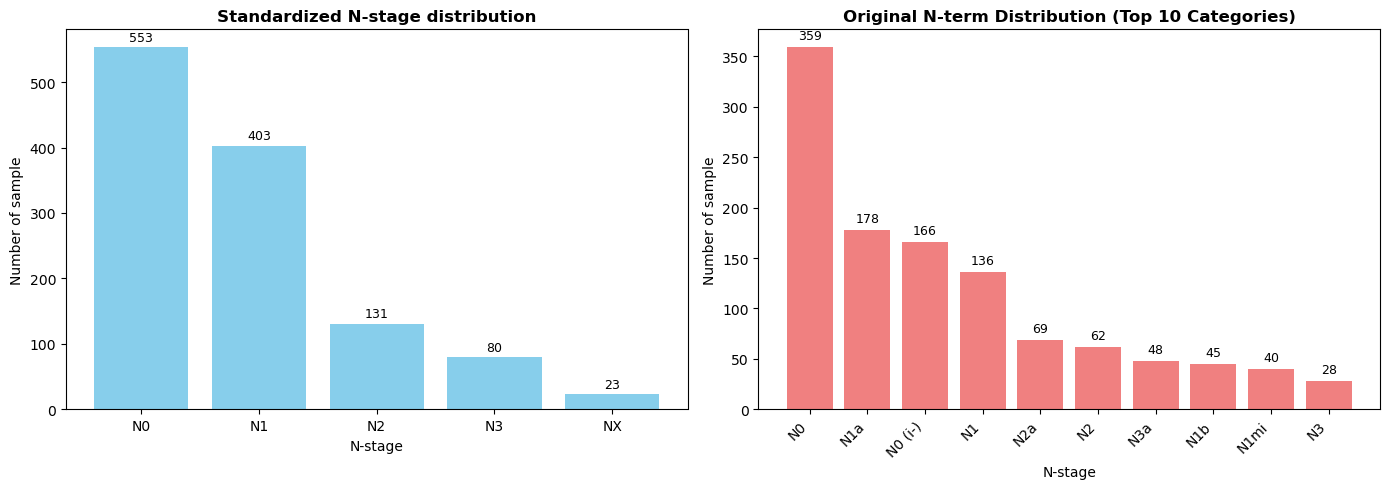

*Figure retained from the original homework run; not regenerated.*


## 2. Compare feature representations

ANOVA selects 1,000 features; separate exploratory branches compute 50 PCs and the top 500 RF-ranked features. The downstream classifier comparison uses **ANOVA features**, not all three representations.


In [ ]:
print("\n" + "="*50)
print("8. Feature Selection Optimization")
print("="*50)

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

print("1. ANOVA-based feature selection...")
anova_selector = SelectKBest(score_func=f_classif, k=1000)
X_anova = anova_selector.fit_transform(X_train, y_train)
X_test_anova = anova_selector.transform(X_test)

print(f"Number of features after ANOVA selection: {X_anova.shape[1]}")

print("\n2. PCA dimensionality reduction...")
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Number of features after PCA: {X_pca.shape[1]}")
print(f"Explained variance ratio by PCA: {np.sum(pca.explained_variance_ratio_):.4f}")

print("\n3. Feature selection based on Random Forest importance...")

from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

top_500_features = rf_importance.head(500)['feature'].tolist()
X_rf_selected = X_train[top_500_features]
X_test_rf_selected = X_test[top_500_features]

print(f"Number of features after Random Forest selection: {X_rf_selected.shape[1]}")


## 3. Tune the random forest

The original randomized search uses 50 candidates, three-fold CV and ROC-AUC scoring. Its recorded best CV AUC is **0.6763**. ANOVA was fitted once before this search, so that CV score is not from fold-contained feature selection.


In [ ]:
print("\n" + "="*50)
print("9. Hyperparameter Tuning")
print("="*50)

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

print("Optimizing Random Forest parameters with Randomized Search...")
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# ANOVA was fitted before this CV search in the original workflow.
random_search.fit(X_anova, y_train)

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best cross-validation AUC: {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_


## 4. Compare classifiers and a voting ensemble

Random forest, XGBoost, LightGBM and gradient boosting are evaluated on the same test split. A soft-voting ensemble combines RF, XGBoost and LightGBM. Model definitions and original hyperparameters are retained.


In [ ]:
print("\n" + "="*50)
print("10. Model Ensemble and Comparison")
print("="*50)

from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                             VotingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    'Random Forest': RandomForestClassifier(
        **random_search.best_params_,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )
}

print("Training and comparing different models...")
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_anova, y_train)
    y_pred = model.predict(X_test_anova)
    y_pred_proba = model.predict_proba(X_test_anova)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }
    
    print(f"  AUC: {auc:.4f}, F1: {f1:.4f}, Accuracy: {accuracy:.4f}")

print("\nTraining ensemble model...")

voting_clf = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost']),
        ('lgbm', models['LightGBM'])
    ],
    voting='soft'
)


In [ ]:
voting_clf.fit(X_anova, y_train)
y_pred_voting = voting_clf.predict(X_test_anova)
y_pred_proba_voting = voting_clf.predict_proba(X_test_anova)[:, 1]

voting_accuracy = accuracy_score(y_test, y_pred_voting)
voting_auc = roc_auc_score(y_test, y_pred_proba_voting)
voting_f1 = f1_score(y_test, y_pred_voting)

results['Voting Ensemble'] = {
    'accuracy': voting_accuracy,
    'precision': precision_score(y_test, y_pred_voting),
    'recall': recall_score(y_test, y_pred_voting),
    'f1': voting_f1,
    'auc': voting_auc
}

print(f"Ensemble model - AUC: {voting_auc:.4f}, F1: {voting_f1:.4f}")


## 5. Summarize scores and RF feature importance

Importance values come from the separate **RF feature selector**, not from LightGBM. Gene IDs are already present in `X_train.columns`; redundant anonymous-feature remapping has been removed. These rankings are exploratory, not validated metastasis markers.


In [ ]:
print("\n" + "="*50)
print("11. Model Performance Visualization")
print("="*50)

rf_importance_mapped = rf_importance.copy()

results_df = pd.DataFrame(results).T

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

models_list = results_df.index.tolist()
auc_values = results_df['auc'].tolist()

sorted_idx = np.argsort(auc_values)
models_sorted = [models_list[i] for i in sorted_idx]
auc_sorted = [auc_values[i] for i in sorted_idx]

bars1 = axes[0, 0].barh(range(len(models_sorted)), auc_sorted, color='steelblue')
axes[0, 0].set_yticks(range(len(models_sorted)))
axes[0, 0].set_yticklabels(models_sorted, fontsize=10)
axes[0, 0].set_xlabel('AUC', fontsize=11)
axes[0, 0].set_title('AUC Comparison Across Models', fontsize=13, fontweight='bold')
axes[0, 0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random Guess')
axes[0, 0].axvline(x=0.6, color='orange', linestyle='--', alpha=0.5, label='Baseline (0.6)')
axes[0, 0].legend()

for i, (bar, value) in enumerate(zip(bars1, auc_sorted)):
    axes[0, 0].text(value + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{value:.4f}', ha='left', va='center', fontsize=9)

    if value < 0.6:
        bar.set_color('lightcoral')

f1_values = results_df['f1'].tolist()
f1_sorted = [f1_values[i] for i in sorted_idx]

bars2 = axes[0, 1].barh(range(len(models_sorted)), f1_sorted, color='darkorange')
axes[0, 1].set_yticks(range(len(models_sorted)))
axes[0, 1].set_yticklabels(models_sorted, fontsize=10)
axes[0, 1].set_xlabel('F1 Score', fontsize=11)
axes[0, 1].set_title('F1 Score Comparison Across Models', fontsize=13, fontweight='bold')

for i, (bar, value) in enumerate(zip(bars2, f1_sorted)):
    axes[0, 1].text(value + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{value:.4f}', ha='left', va='center', fontsize=9)

acc_values = results_df['accuracy'].tolist()
acc_sorted = [acc_values[i] for i in sorted_idx]

bars3 = axes[1, 0].barh(range(len(models_sorted)), acc_sorted, color='forestgreen')
axes[1, 0].set_yticks(range(len(models_sorted)))
axes[1, 0].set_yticklabels(models_sorted, fontsize=10)
axes[1, 0].set_xlabel('Accuracy', fontsize=11)
axes[1, 0].set_title('Accuracy Comparison Across Models', fontsize=13, fontweight='bold')

for i, (bar, value) in enumerate(zip(bars3, acc_sorted)):
    axes[1, 0].text(value + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{value:.4f}', ha='left', va='center', fontsize=9)

if 'rf_importance_mapped' in locals() or 'rf_importance_mapped' in globals():

    top_features = rf_importance_mapped.head(20).copy()

    def truncate_gene_name(name, max_length=30):
        if isinstance(name, str) and len(name) > max_length:
            return name[:max_length-3] + '...'
        return name
    
    top_features['feature_truncated'] = top_features['feature'].apply(truncate_gene_name)

    y_pos = np.arange(len(top_features))
    bars4 = axes[1, 1].barh(y_pos, top_features['importance'], color='darkblue')
    axes[1, 1].set_yticks(y_pos)
    axes[1, 1].set_yticklabels(top_features['feature_truncated'], fontsize=9)
    axes[1, 1].set_xlabel('Importance Score', fontsize=11)
    axes[1, 1].set_title('Top 20 Important Gene Features (Real Gene Names)', fontsize=13, fontweight='bold')
    axes[1, 1].invert_yaxis()

    for bar, importance in zip(bars4, top_features['importance']):
        width = bar.get_width()
        axes[1, 1].text(width + 0.001, bar.get_y() + bar.get_height()/2,
                       f'{importance:.4f}', ha='left', va='center', fontsize=8)
    
    print("\nTop 20 important genes (full names):")
    for i, row in top_features.iterrows():
        print(f"  {row['feature_truncated']} -> Importance: {row['importance']:.6f}")
else:

    metrics_to_compare = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    x = np.arange(len(models_list))
    width = 0.15

    for i, metric in enumerate(metrics_to_compare):
        offset = (i - len(metrics_to_compare)/2) * width
        values = results_df[metric].tolist()
        axes[1, 1].bar(x + offset, values, width, label=metric, alpha=0.7)

    axes[1, 1].set_xlabel('Model', fontsize=11)
    axes[1, 1].set_ylabel('Score', fontsize=11)
    axes[1, 1].set_title('Multi-metric Comparison Across Models', fontsize=13, fontweight='bold')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(models_list, rotation=45, ha='right', fontsize=10)
    axes[1, 1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    axes[1, 1].grid(True, axis='y', alpha=0.3)
    axes[1, 1].set_ylim([0, 1])


In [ ]:
plt.tight_layout()
plt.show()


## 6. Inspect the selected model and ROC curve

LightGBM had the highest recorded test AUC (**0.6225**), with accuracy **0.5812** and F1 **0.6316**. The original workflow selected the model using this same test set, so this is not an independent final evaluation.


In [ ]:
print("\n" + "="*50)
print("13. Final Training with Best Model")
print("="*50)

# This comparison reuses the test set; it is not independent final validation.
best_model_name = results_df['auc'].idxmax()
best_model_auc = results_df.loc[best_model_name, 'auc']

print(f"Best model: {best_model_name} (AUC: {best_model_auc:.4f})")

if best_model_name == 'Voting Ensemble':

    final_model = voting_clf
else:

    final_model = models[best_model_name]
    final_model.fit(X_anova, y_train)

y_pred_final = final_model.predict(X_test_anova)
y_pred_proba_final = final_model.predict_proba(X_test_anova)[:, 1]

final_accuracy = accuracy_score(y_test, y_pred_final)
final_auc = roc_auc_score(y_test, y_pred_proba_final)
final_f1 = f1_score(y_test, y_pred_final)

print(f"\nFinal model performance:")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"AUC: {final_auc:.4f}")
print(f"F1 Score: {final_f1:.4f}")

print("\nFinal classification report:")
print(classification_report(y_test, y_pred_final, target_names=['N0', 'N+']))

plt.figure(figsize=(10, 8))
fpr_final, tpr_final, _ = roc_curve(y_test, y_pred_proba_final)

plt.plot(fpr_final, tpr_final, color='darkred', lw=3, 
         label=f'{best_model_name} (AUC = {final_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'Selected Model ROC Curve ({best_model_name})', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Recorded model comparison

| Model | Test ROC-AUC | F1 | Accuracy |
| --- | ---: | ---: | ---: |
| Random forest | 0.5946 | 0.6618 | 0.6026 |
| XGBoost | 0.5987 | 0.6449 | 0.5812 |
| LightGBM | 0.6225 | 0.6316 | 0.5812 |
| Gradient boosting | 0.6147 | 0.6642 | 0.6068 |
| Soft-voting ensemble | 0.6098 | 0.6493 | Not printed in the saved summary |

Numbers are copied from the original saved output, not recalculated.


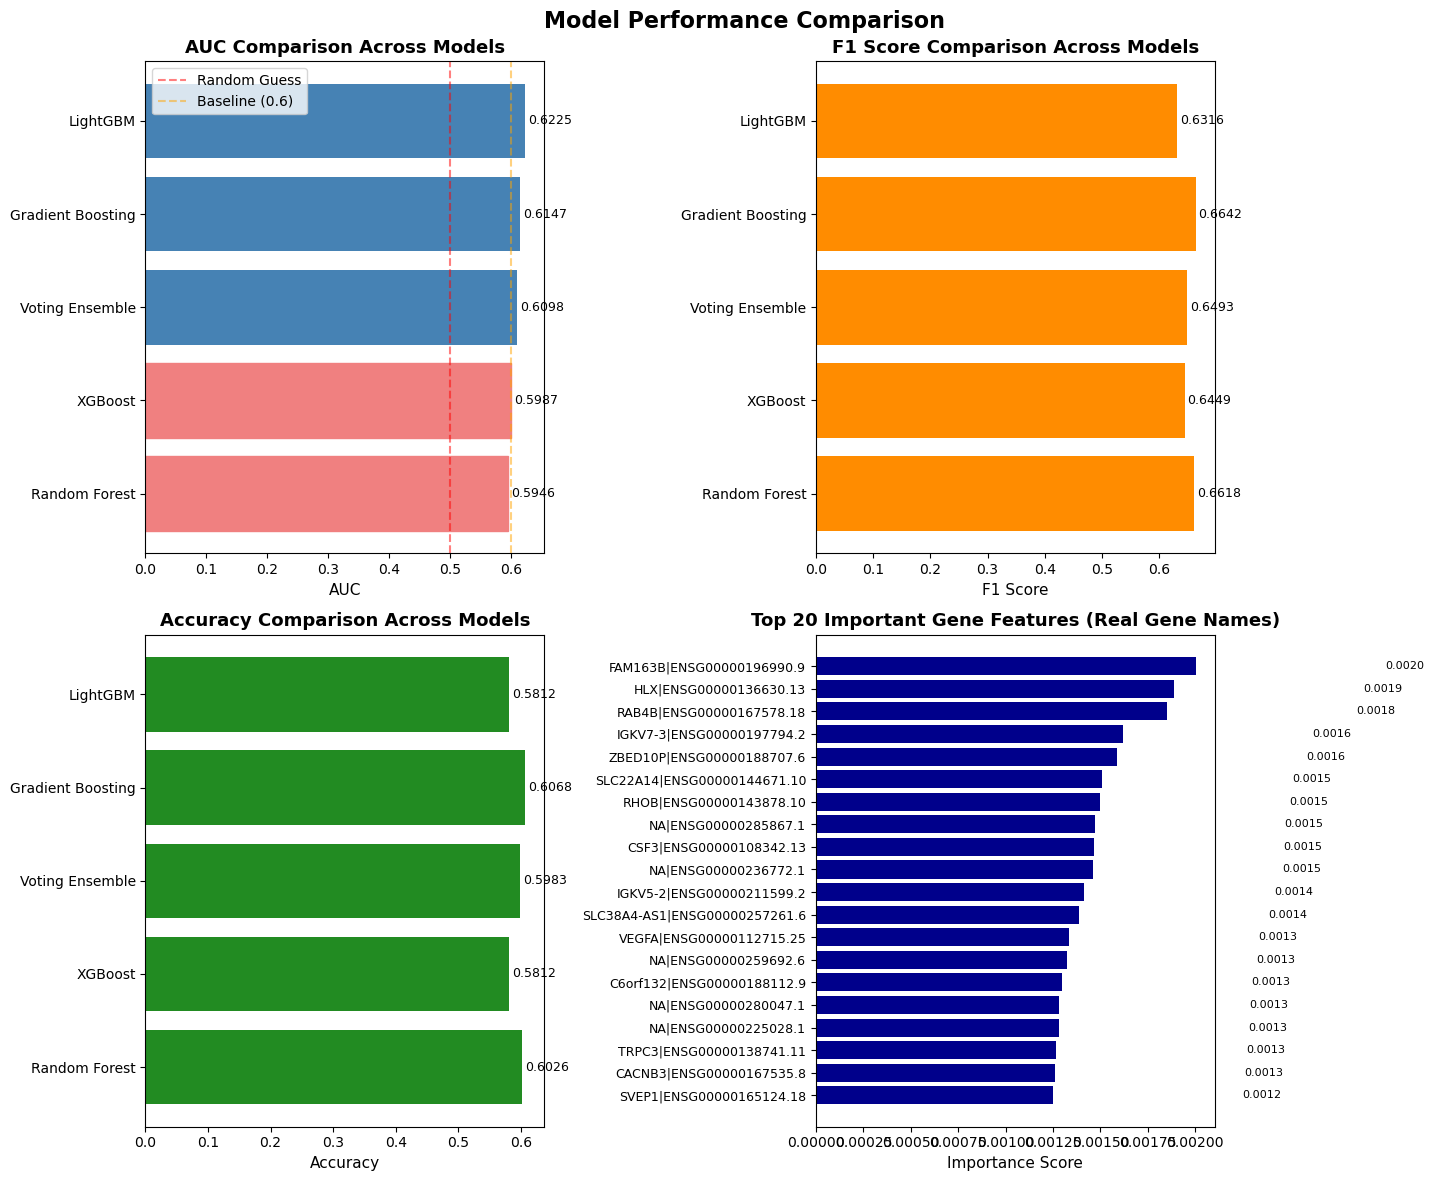

*Figure retained from the original run. The feature-importance panel refers to the RF selector.*


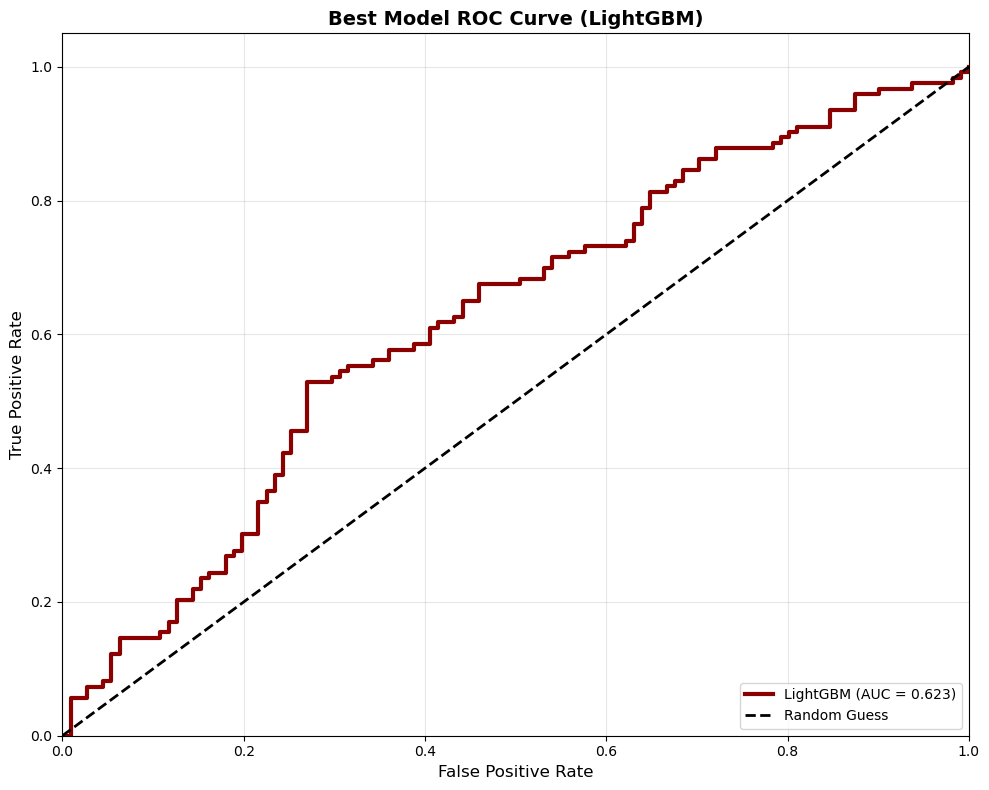

*Figure retained from the original run. The feature-importance panel refers to the RF selector.*


## 7. Interpretation and limitations

Recorded AUC point estimates were above 0.5 but modest. No confidence interval or
formal comparison with chance was calculated, so these observations do not prove
the original hypothesis or establish clinical usefulness.

Several aspects limit interpretation: the course input includes normal tissue;
the code filters N-stage availability but does not restrict sample type; multiple
samples per patient are possible; variance filtering precedes the test split; ANOVA
precedes CV; and the model is selected using test-set scores. These choices are
documented rather than silently replaced in an edition that has not been rerun.

Unused interaction and cluster-feature experiments were removed because they did
not enter the reported models. The original model comparisons and final ROC output
remain intact. Patient-grouped validation on a defined tumor cohort would be needed
before treating the results as evidence of metastasis prediction.

[Original saved text output](../results/lymph_node/original_stdout.txt) ·
[Editorial notes](../docs/editorial_notes.md)
